In [ ]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr

import jax
import jax.numpy as jnp
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.bijectors as tfb

In [ ]:
# Define list of brand variables to use as labels
param_names = ["Blue Bonnet", "Fleischmanns", "House", "Generic", "Shed Spread", "log(price)"]

In [ ]:
# ==========================================
# 2. LOAD SAMPLES FROM 'Data' FOLDER
# ==========================================
data_dir = "Data"
liesel_path = os.path.join(data_dir, "liesel_posterior_samples_demeaned.pkl")
bayesm_path = os.path.join(data_dir, "bayesm_output_margarine_demeaned.RData")

# Load Liesel Samples
print(f"Loading Liesel samples from {liesel_path}...")
with open(liesel_path, "rb") as f:
    liesel_samples = pickle.load(f)

# Load Bayesm Samples
print(f"Loading Bayesm samples from {bayesm_path}...")
bayesm_res = pyreadr.read_r(bayesm_path)

# Extract DataFrames from the pyreadr dictionary
# pyreadr returns a dict where keys are the R object names
bayesm_mu_df = bayesm_res['mu_draws_df']
bayesm_delta_df = bayesm_res['delta_draws_df']

# Convert to numpy arrays for easier plotting
bayesm_mu = bayesm_mu_df.values

Loading Liesel samples from Data\liesel_posterior_samples_demeaned.pkl...
Loading Bayesm samples from Data\bayesm_output_margarine_demeaned.RData...


In [ ]:
# ==========================================
# 3. EXTRACT COMPARABLE PARAMETERS
# ==========================================
# In Bayesm, 'mu_draws' represents the baseline means for the mixture components.
# Because the demographic variables (Z) were de-meaned, these 'mu' values correspond 
# to the baseline utility and price sensitivity for the "average" household.

n_demos = 3 # Intercept, log(Income), Family Size
k_dim = len(param_names)

# Flatten the chains and draws: (chains, draws, n_z, k_dim) -> (total_draws, n_z, k_dim)
delta_reshaped = liesel_samples["Delta"].reshape(-1, n_demos, k_dim)

# Extract the base intercept (demographic index 0) for all draws
# Shape becomes (total_draws, k_dim)
liesel_mu = delta_reshaped[:, 0, :]

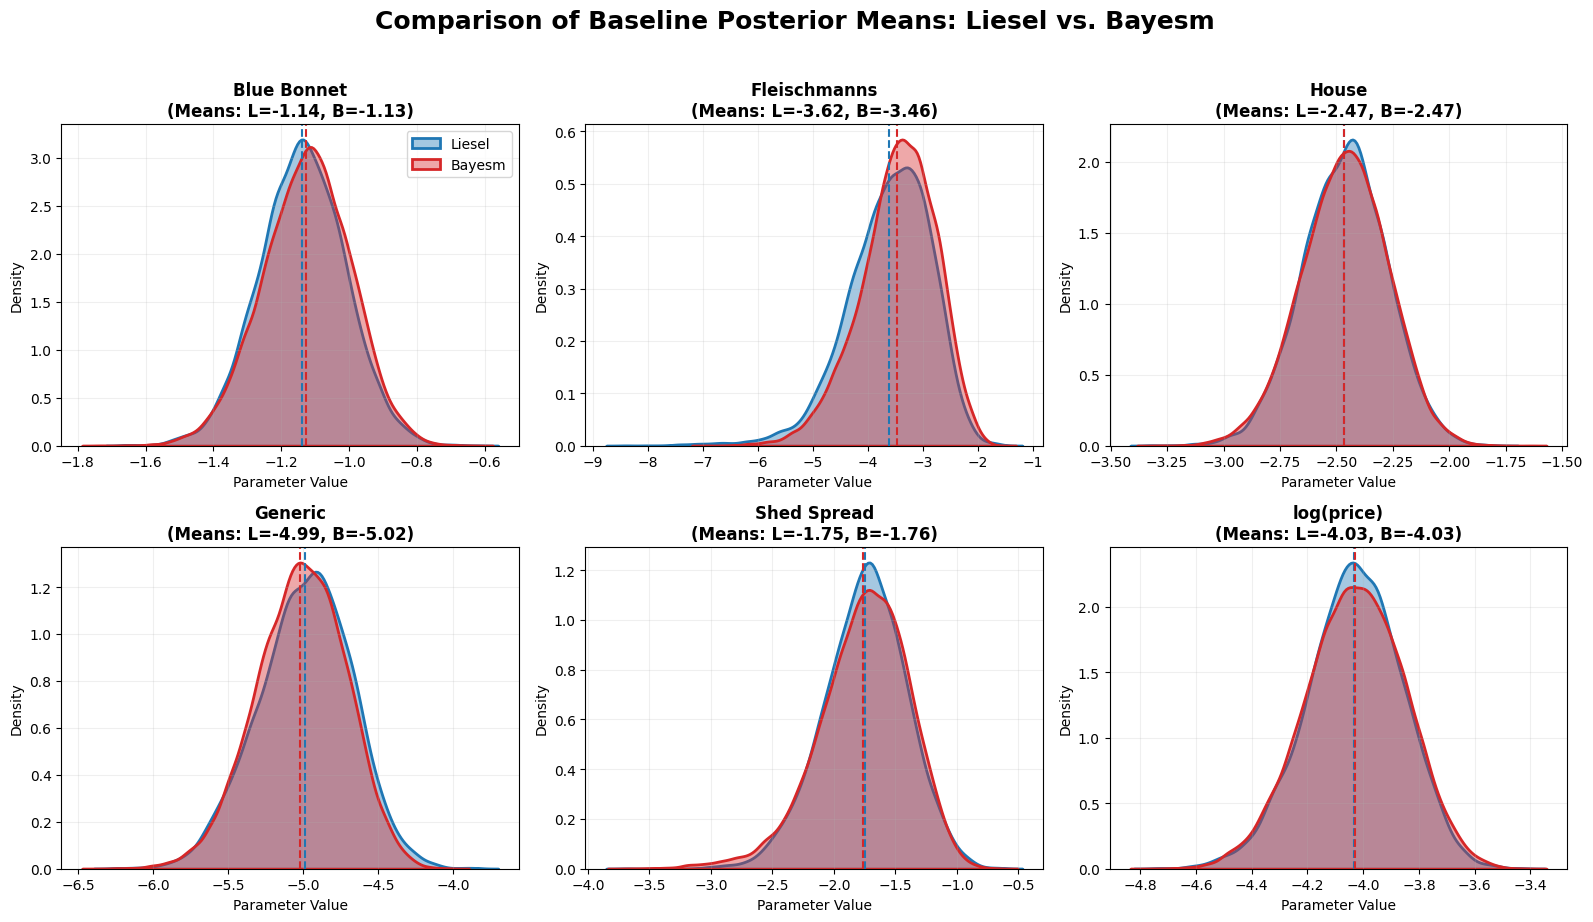

In [ ]:
# ==========================================
# 4. PLOT COMPARISONS (Base Intercepts)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Colors to distinguish the models
color_liesel = "#1f77b4" # Blue
color_bayesm = "#d62728" # Red

for i, param in enumerate(param_names):
    ax = axes[i]
    
    # Extract the 1D array of 10,000 draws for this specific parameter
    liesel_draws_1d = liesel_mu[:, i]
    bayesm_draws_1d = bayesm_mu[:, i]
    
    # Plot Liesel
    sns.kdeplot(liesel_draws_1d, ax=ax, fill=True, color=color_liesel, alpha=0.4, 
                linewidth=2, label="Liesel")
    
    # Plot Bayesm
    sns.kdeplot(bayesm_draws_1d, ax=ax, fill=True, color=color_bayesm, alpha=0.4, 
                linewidth=2, label="Bayesm")
    
    # Calculate and plot means as vertical lines
    mean_liesel = np.mean(liesel_draws_1d)
    mean_bayesm = np.mean(bayesm_draws_1d)
    ax.axvline(mean_liesel, color=color_liesel, linestyle="--", linewidth=1.5)
    ax.axvline(mean_bayesm, color=color_bayesm, linestyle="--", linewidth=1.5)
    
    ax.set_title(f"{param}\n(Means: L={mean_liesel:.2f}, B={mean_bayesm:.2f})", 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Parameter Value")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.2)
    
    # Only add the legend to the first subplot to keep it clean
    if i == 0:
        ax.legend(fontsize=10, loc="upper right")

plt.suptitle("Comparison of Baseline Posterior Means: Liesel vs. Bayesm", 
             y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()

In [ ]:
# ==========================================
# 5. POSTERIOR TABLES (DELTA & COVARIANCE)
# ==========================================

demo_names = ["Intercept", "log(Income)", "Family size"]
n_demos = len(demo_names)
k_dim = len(param_names)

def generate_delta_table(delta_draws, param_names, demo_names):
    """Calculates posterior means and stds for Delta, returning a formatted DataFrame."""
    delta_mean = np.mean(delta_draws, axis=0)
    delta_std = np.std(delta_draws, axis=0)

    delta_df = pd.DataFrame(index=demo_names, columns=param_names)
    for i in range(len(demo_names)):
        for j in range(len(param_names)):
            delta_df.iloc[i, j] = f"{delta_mean[i, j]: .2f} ({delta_std[i, j]:.2f})"
            
    return delta_df

def generate_liesel_cov_corr(samples, param_names):
    """Calculates posterior stds and correlations of Betas from Liesel's latent samples."""
    k_dim = len(param_names)
    latent_samples = samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
    bijector = tfb.FillScaleTriL()

    def latent_to_cov(latent_vec):
        L = bijector.forward(latent_vec)
        precision_mat = L @ L.T
        return jnp.linalg.inv(precision_mat)

    v_latent_to_cov = jax.vmap(latent_to_cov)
    cov_draws = np.array(v_latent_to_cov(latent_samples)) 

    std_draws = np.sqrt(np.diagonal(cov_draws, axis1=1, axis2=2))
    outer_stds = std_draws[:, :, None] * std_draws[:, None, :]
    corr_draws = cov_draws / outer_stds

    std_mean = np.mean(std_draws, axis=0)
    std_sd = np.std(std_draws, axis=0)
    corr_mean = np.mean(corr_draws, axis=0)
    corr_sd = np.std(corr_draws, axis=0)

    cov_corr_df = pd.DataFrame(index=param_names, columns=param_names)
    for i in range(k_dim):
        for j in range(k_dim):
            if i == j:
                cov_corr_df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i:
                cov_corr_df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else:
                cov_corr_df.iloc[i, j] = ""
                
    return cov_corr_df

def generate_bayesm_cov_corr(bayesm_res, param_names):
    """Calculates posterior stds and correlations of Betas from Bayesm's exported covariance draws."""
    k_dim = len(param_names)
    
    # 1. Load the flat 2D dataframe exported from R
    bayesm_cov_df = bayesm_res['cov_draws_df']
    
    # 2. Reshape back to (N_draws, k_dim, k_dim). 
    # Use order='F' because R flattened the matrix columns into the vector.
    cov_draws = bayesm_cov_df.values.reshape((-1, k_dim, k_dim), order='F')
    
    # 3. Calculate Standard Deviations (sqrt of diagonal)
    std_draws = np.sqrt(np.diagonal(cov_draws, axis1=1, axis2=2))
    
    # 4. Calculate Correlations: Corr(i,j) = Cov(i,j) / (Std(i) * Std(j))
    outer_stds = std_draws[:, :, None] * std_draws[:, None, :]
    corr_draws = cov_draws / outer_stds
    
    # 5. Compute posterior means and SDs
    std_mean = np.mean(std_draws, axis=0)
    std_sd = np.std(std_draws, axis=0)
    corr_mean = np.mean(corr_draws, axis=0)
    corr_sd = np.std(corr_draws, axis=0)
    
    # 6. Format into a DataFrame
    cov_corr_df = pd.DataFrame(index=param_names, columns=param_names)
    for i in range(k_dim):
        for j in range(k_dim):
            if i == j:
                cov_corr_df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i:
                cov_corr_df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else:
                cov_corr_df.iloc[i, j] = ""
                
    return cov_corr_df

# --- 1. Prepare Delta Draws for both models ---
liesel_delta_draws = liesel_samples["Delta"].reshape(-1, n_demos, k_dim)

n_bayesm_draws = bayesm_delta_df.shape[0]
bayesm_delta_only = np.zeros((n_bayesm_draws, 2, k_dim)) 

for i in range(n_bayesm_draws):
    # Remember: Keep this as order='C' based on our previous fix!
    bayesm_delta_only[i] = bayesm_delta_df.values[i].reshape((2, k_dim), order='C')

bayesm_mu_expanded = bayesm_mu.reshape(-1, 1, k_dim)
bayesm_delta_draws = np.concatenate([bayesm_mu_expanded, bayesm_delta_only], axis=1)

# --- 2. Generate the DataFrames ---
df_delta_liesel = generate_delta_table(liesel_delta_draws, param_names, demo_names)
df_delta_bayesm = generate_delta_table(bayesm_delta_draws, param_names, demo_names)

df_cov_corr_liesel = generate_liesel_cov_corr(liesel_samples, param_names)
df_cov_corr_bayesm = generate_bayesm_cov_corr(bayesm_res, param_names)

# --- 3. Display the Output ---
print("=== Posterior distribution of Delta (Liesel) ===")
display(df_delta_liesel)

print("\n=== Posterior distribution of Delta (Bayesm) ===")
display(df_delta_bayesm)

print("\n=== Correlations and standard deviations of betas (Liesel) ===")
display(df_cov_corr_liesel)

print("\n=== Correlations and standard deviations of betas (Bayesm) ===")
display(df_cov_corr_bayesm)

KeyError: 'cov_draws_df'